# Comparação de Modelos — Mobile Price Classification
Rede Neural (MLP) vs. Random Forest

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

from Neural_Network import NeuralNetwork

## 1. Carregamento e Pré-processamento

In [3]:
data_path = os.path.join("..", "Database", "train.csv")
df = pd.read_csv(data_path)

print(f"Dataset carregado: {df.shape[0]} amostras, {df.shape[1]} colunas")
display(df.head())

feature_names = df.drop(columns=["price_range"]).columns.tolist()
X = df.drop(columns=["price_range"]).values.astype(float)
y = df["price_range"].values

X_min  = X.min(axis=0)
X_max  = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min + 1e-8)

split       = int(0.7 * len(X_norm))
X_tr, X_val = X_norm[:split], X_norm[split:]
y_tr, y_val = y[:split], y[split:]

class_names = ["Preco Baixo", "Preco Medio", "Preco Alto", "Preco Muito Alto"]

print(f"\nTreino   : {X_tr.shape[0]} amostras")
print(f"Validacao: {X_val.shape[0]} amostras")

Dataset carregado: 2000 amostras, 21 colunas


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



Treino   : 1400 amostras
Validacao: 600 amostras


## 2. Modelo 1 — Rede Neural (MLP)

In [5]:
print("Treinando a Rede Neural...")
nn = NeuralNetwork(layer_sizes=[20, 16, 8, 4], seed=127)
print(nn)

history_nn = nn.train(X_tr, y_tr, epochs=10000, learning_rate=0.01,
                      verbose=True, print_every=100)
predicoes_nn_tr, _     = nn.predict(X_tr)
predicoes_nn, probs_nn = nn.predict(X_val)
print(f"Acuracia Treino    : {accuracy_score(y_tr,  predicoes_nn_tr)*100:.2f}%")
print(f"Acuracia Validacao : {accuracy_score(y_val, predicoes_nn)*100:.2f}%")

Treinando a Rede Neural...
NeuralNet(20 -> 16 -> 8 -> 4)
Epoca   100/10000 — Custo: 1.4176
Epoca   200/10000 — Custo: 1.3910
Epoca   300/10000 — Custo: 1.3761
Epoca   400/10000 — Custo: 1.3654
Epoca   500/10000 — Custo: 1.3545
Epoca   600/10000 — Custo: 1.3424
Epoca   700/10000 — Custo: 1.3288
Epoca   800/10000 — Custo: 1.3121
Epoca   900/10000 — Custo: 1.2906
Epoca  1000/10000 — Custo: 1.2629
Epoca  1100/10000 — Custo: 1.2276
Epoca  1200/10000 — Custo: 1.1837
Epoca  1300/10000 — Custo: 1.1315
Epoca  1400/10000 — Custo: 1.0718
Epoca  1500/10000 — Custo: 1.0076
Epoca  1600/10000 — Custo: 0.9427
Epoca  1700/10000 — Custo: 0.8797
Epoca  1800/10000 — Custo: 0.8205
Epoca  1900/10000 — Custo: 0.7664
Epoca  2000/10000 — Custo: 0.7174
Epoca  2100/10000 — Custo: 0.6731
Epoca  2200/10000 — Custo: 0.6332
Epoca  2300/10000 — Custo: 0.5971
Epoca  2400/10000 — Custo: 0.5642
Epoca  2500/10000 — Custo: 0.5340
Epoca  2600/10000 — Custo: 0.5064
Epoca  2700/10000 — Custo: 0.4813
Epoca  2800/10000 — Custo

### Curva de Aprendizado — Rede Neural

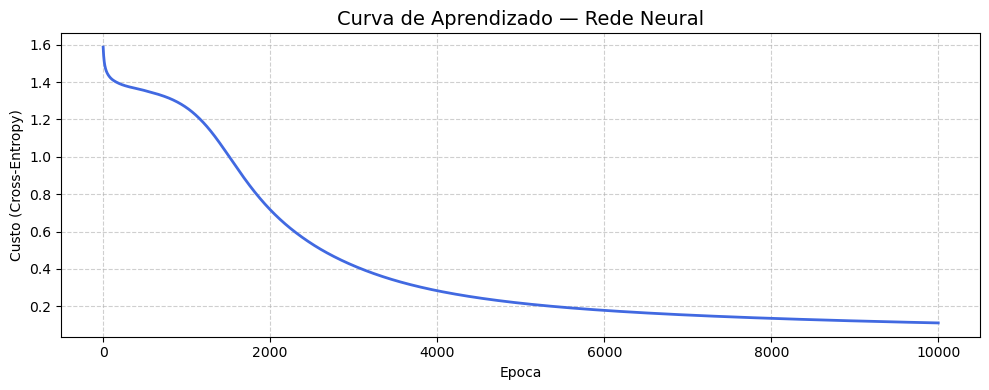

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(history_nn, color="royalblue", linewidth=2)
plt.title("Curva de Aprendizado — Rede Neural", fontsize=14)
plt.xlabel("Epoca")
plt.ylabel("Custo (Cross-Entropy)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("curva_aprendizado.png", dpi=150)
plt.show()

## 3. Modelo 2 — Random Forest

### 3a. Busca de Hiperparâmetros (opcional)

In [ ]:
# Descomente para rodar a busca (~alguns minutos)

# param_dist = {
#     'n_estimators'    : randint(200, 800),
#     'max_features'    : uniform(0.3, 0.5),
#     'max_depth'       : [None, 10, 20, 30],
#     'min_samples_split': randint(2, 10),
#     'min_samples_leaf' : randint(1, 5),
# }
# rf_base = RandomForestClassifier(random_state=42)
# random_search = RandomizedSearchCV(
#     estimator=rf_base, param_distributions=param_dist,
#     n_iter=30, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
# )
# random_search.fit(X_tr, y_tr)
# print("Acuracia CV maxima :", random_search.best_score_)
# print("Melhores parametros:", random_search.best_params_)

print("Busca comentada. Usando os melhores parametros ja encontrados.")

### 3b. Treino com os Melhores Hiperparâmetros

In [7]:
print("Treinando o Random Forest...")
rf = RandomForestClassifier(
    n_estimators=675,
    max_features=0.6059264473611897,
    max_depth=20,
    min_samples_split=9,
    min_samples_leaf=2,
    random_state=42,
    oob_score=True
)
rf.fit(X_tr, y_tr)

predicoes_rf  = rf.predict(X_val)
probs_rf      = rf.predict_proba(X_val)

print(f"Acuracia na Validacao : {accuracy_score(y_val, predicoes_rf)*100:.2f}%")
print(f"OOB Score (estimativa): {rf.oob_score_*100:.2f}%")

Treinando o Random Forest...
Acuracia na Validacao : 89.67%
OOB Score (estimativa): 89.64%


### Grafico 1 — Importância das Features

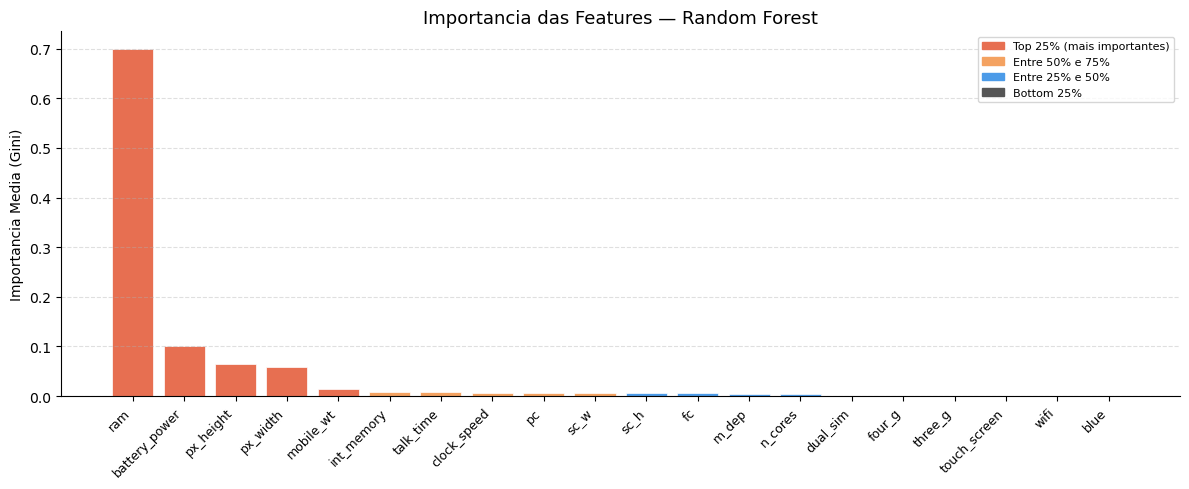

In [8]:
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_imp   = importances[indices]

# Colorir por quartil de importância
quartiles = np.percentile(sorted_imp, [25, 50, 75])
bar_colors = []
for v in sorted_imp:
    if v >= quartiles[2]:   bar_colors.append("#E76F51")
    elif v >= quartiles[1]: bar_colors.append("#F4A261")
    elif v >= quartiles[0]: bar_colors.append("#4C9BE8")
    else:                   bar_colors.append("#555555")

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(sorted_names)), sorted_imp, color=bar_colors,
              edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels(sorted_names, rotation=45, ha="right", fontsize=9)
ax.set_title("Importancia das Features — Random Forest", fontsize=13)
ax.set_ylabel("Importancia Media (Gini)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
legend_els = [
    Patch(color="#E76F51", label="Top 25% (mais importantes)"),
    Patch(color="#F4A261", label="Entre 50% e 75%"),
    Patch(color="#4C9BE8", label="Entre 25% e 50%"),
    Patch(color="#555555", label="Bottom 25%"),
]
ax.legend(handles=legend_els, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

### Grafico 2 — Acurácia vs. Número de Árvores

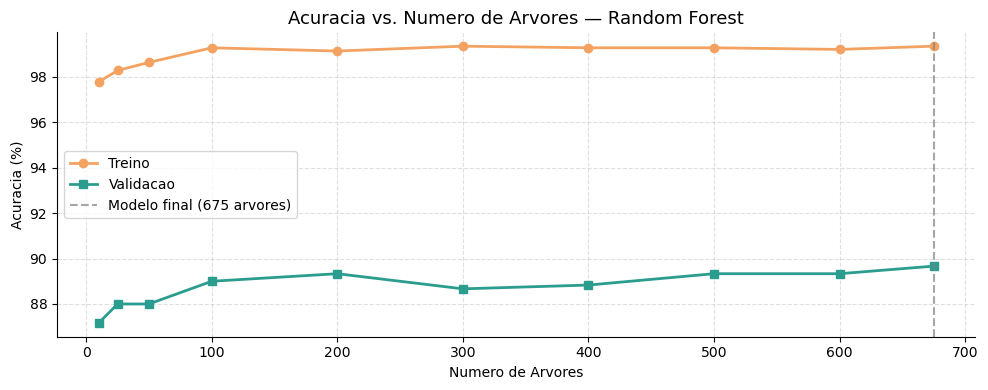

In [9]:
tree_counts = [10, 25, 50, 100, 200, 300, 400, 500, 600, 675]
accs_tr, accs_val = [], []

for n in tree_counts:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        max_features=0.6059264473611897,
        max_depth=20,
        min_samples_split=9,
        min_samples_leaf=2,
        random_state=42
    )
    rf_tmp.fit(X_tr, y_tr)
    accs_tr.append(accuracy_score(y_tr,  rf_tmp.predict(X_tr))  * 100)
    accs_val.append(accuracy_score(y_val, rf_tmp.predict(X_val)) * 100)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tree_counts, accs_tr,  marker="o", color="#F4A261", linewidth=2, label="Treino")
ax.plot(tree_counts, accs_val, marker="s", color="#2A9D8F", linewidth=2, label="Validacao")
ax.axvline(x=675, color="gray", linestyle="--", alpha=0.7, label="Modelo final (675 arvores)")
ax.set_title("Acuracia vs. Numero de Arvores — Random Forest", fontsize=13)
ax.set_xlabel("Numero de Arvores")
ax.set_ylabel("Acuracia (%)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("rf_n_estimators.png", dpi=150)
plt.show()

### Grafico 3 — Distribuição da Confiança por Classe

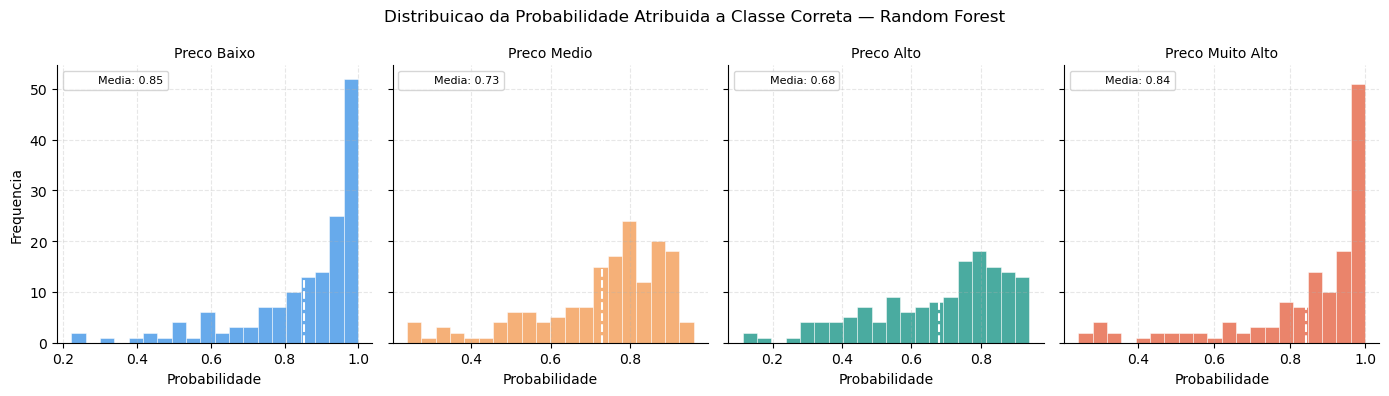

In [10]:
colors_cls = ["#4C9BE8", "#F4A261", "#2A9D8F", "#E76F51"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle("Distribuicao da Probabilidade Atribuida a Classe Correta — Random Forest",
             fontsize=12)

for k, ax in enumerate(axes):
    mask  = y_val == k
    probs = probs_rf[mask, k]
    ax.hist(probs, bins=20, color=colors_cls[k], edgecolor="white",
            linewidth=0.4, alpha=0.85)
    ax.axvline(probs.mean(), color="white", linestyle="--",
               linewidth=1.5, label=f"Media: {probs.mean():.2f}")
    ax.set_title(class_names[k], fontsize=10)
    ax.set_xlabel("Probabilidade")
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Frequencia")
plt.tight_layout()
plt.savefig("rf_confianca_classes.png", dpi=150)
plt.show()

### Grafico 4 — Top 2 Features: Dispersão com Classes Reais

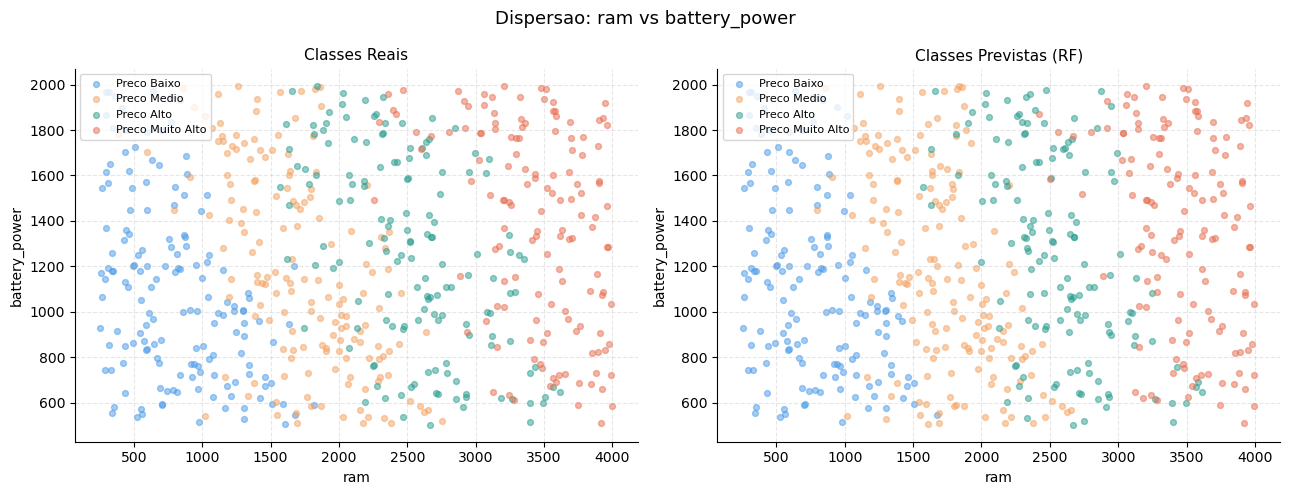

In [12]:
# Pega as 2 features mais importantes
top2_idx   = np.argsort(rf.feature_importances_)[::-1][:2]
top2_names = [feature_names[i] for i in top2_idx]

# Usa dados de validacao (sem normalizar para facilitar leitura)
X_val_orig = X[split:]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

titles  = ["Classes Reais", "Classes Previstas (RF)"]
targets = [y_val, predicoes_rf]

for ax, labels, title in zip(axes, targets, titles):
    for k in range(4):
        mask = labels == k
        ax.scatter(
            X_val_orig[mask, top2_idx[0]],
            X_val_orig[mask, top2_idx[1]],
            label=class_names[k], alpha=0.5,
            s=18, color=colors_cls[k]
        )
    ax.set_xlabel(top2_names[0])
    ax.set_ylabel(top2_names[1])
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Dispersao: {top2_names[0]} vs {top2_names[1]}", fontsize=13)
plt.tight_layout()
plt.savefig("rf_dispersao_top2.png", dpi=150)
plt.show()

## 4. Comparação Final

In [13]:
acc_nn = accuracy_score(y_val, predicoes_nn)
acc_rf = accuracy_score(y_val, predicoes_rf)

print("=" * 52)
print("            RESULTADOS FINAIS")
print("=" * 52)
print(f"Acuracia — Rede Neural  : {acc_nn*100:.2f}%")
print(f"Acuracia — Random Forest: {acc_rf*100:.2f}%")
print()
print("--- Relatorio Detalhado: REDE NEURAL ---")
print(classification_report(y_val, predicoes_nn, target_names=class_names))
print("--- Relatorio Detalhado: RANDOM FOREST ---")
print(classification_report(y_val, predicoes_rf, target_names=class_names))

            RESULTADOS FINAIS
Acuracia — Rede Neural  : 95.67%
Acuracia — Random Forest: 89.67%

--- Relatorio Detalhado: REDE NEURAL ---
                  precision    recall  f1-score   support

     Preco Baixo       0.96      0.99      0.97       154
     Preco Medio       0.95      0.94      0.95       161
      Preco Alto       0.95      0.94      0.94       147
Preco Muito Alto       0.98      0.96      0.97       138

        accuracy                           0.96       600
       macro avg       0.96      0.96      0.96       600
    weighted avg       0.96      0.96      0.96       600

--- Relatorio Detalhado: RANDOM FOREST ---
                  precision    recall  f1-score   support

     Preco Baixo       0.96      0.95      0.96       154
     Preco Medio       0.86      0.91      0.88       161
      Preco Alto       0.85      0.81      0.83       147
Preco Muito Alto       0.91      0.91      0.91       138

        accuracy                           0.90       600
  

### Matrizes de Confusão

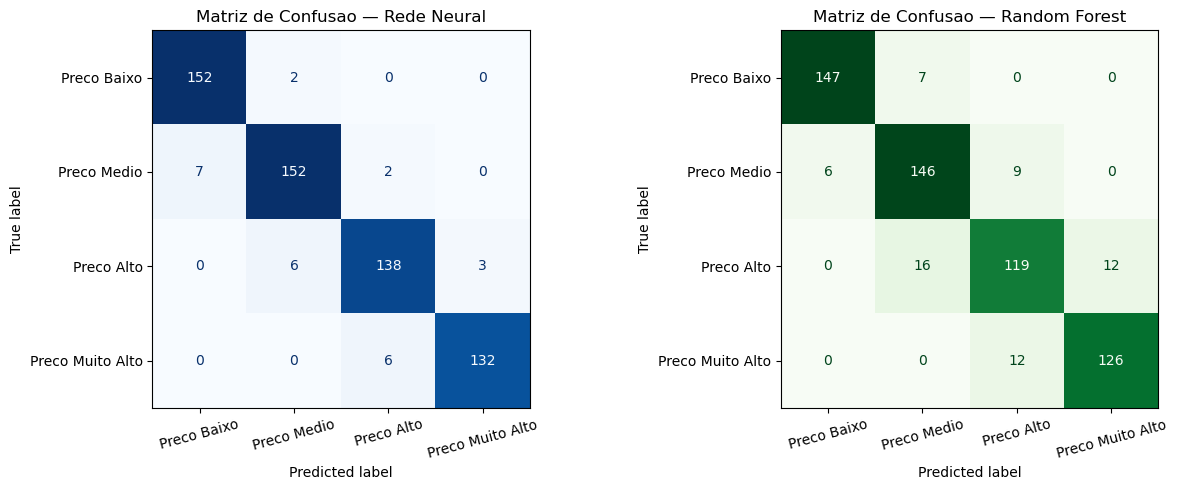

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title, cmap in zip(
    axes,
    [predicoes_nn, predicoes_rf],
    ["Rede Neural", "Random Forest"],
    ["Blues", "Greens"]
):
    cm   = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"Matriz de Confusao — {title}", fontsize=12)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("matrizes_confusao.png", dpi=150)
plt.show()

### Comparação Visual de Acurácia e F1 por Classe

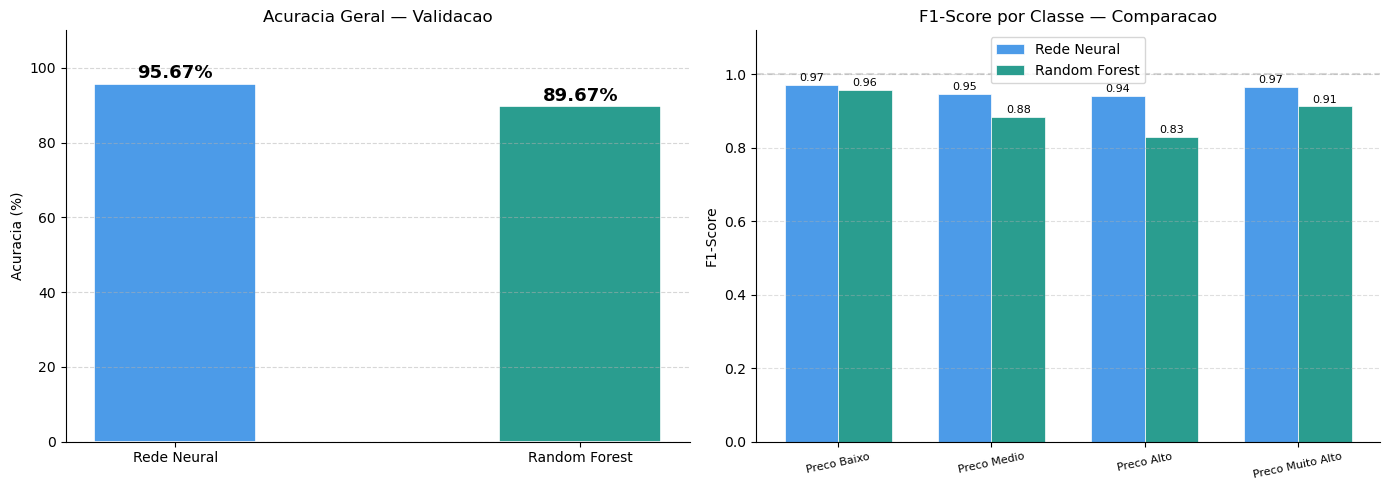

In [15]:
from sklearn.metrics import f1_score

f1_nn = f1_score(y_val, predicoes_nn, average=None)
f1_rf = f1_score(y_val, predicoes_rf, average=None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Acuracia geral ---
ax = axes[0]
modelos   = ["Rede Neural", "Random Forest"]
acuracias = [acc_nn * 100, acc_rf * 100]
cores     = ["#4C9BE8", "#2A9D8F"]
bars = ax.bar(modelos, acuracias, color=cores, width=0.4,
              edgecolor="white", linewidth=1.2)
for bar, acc in zip(bars, acuracias):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc:.2f}%", ha="center", va="bottom",
            fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.set_ylabel("Acuracia (%)")
ax.set_title("Acuracia Geral — Validacao", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# --- F1 por classe ---
ax = axes[1]
x     = np.arange(4)
width = 0.35
b1 = ax.bar(x - width/2, f1_nn, width, label="Rede Neural",
            color="#4C9BE8", edgecolor="white", linewidth=0.5)
b2 = ax.bar(x + width/2, f1_rf, width, label="Random Forest",
            color="#2A9D8F", edgecolor="white", linewidth=0.5)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=12, fontsize=8)
ax.set_ylim(0, 1.12)
ax.set_ylabel("F1-Score")
ax.set_title("F1-Score por Classe — Comparacao", fontsize=12)
ax.legend()
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("comparacao_final.png", dpi=150)
plt.show()